<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1> Módulo 2: Teoría de Redes Neuronales Recurrentes</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>

## Introducción


Los seres humanos no reinician su proceso de pensamiento desde cero a cada instante. Al leer un texto o escuchar una conversación, comprendemos cada palabra en función de las palabras anteriores. Nuestro razonamiento retiene memoria y contexto; **el pensamiento tiene persistencia**.

Las redes neuronales tradicionales (*Feedforward Neural Networks*) no pueden modelar este comportamiento temporal, lo cual representa una limitación fundamental. Por ejemplo, si quisiéramos clasificar qué tipo de evento ocurre en cada fotograma de un video o predecir la siguiente palabra en un enunciado, una red densa estándar no puede transferir información de instantes pasados a los futuros de forma natural.

Las **Redes Neuronales Recurrentes (RNN)** abordan directamente esta limitación incorporando **conexiones de retroalimentación (bucles)** en su arquitectura interna, lo que permite que la información persista a través del tiempo.

<img src="Figures/RNN-rolled.png" alt="RNN con bucle" style="display: block; margin: 0 auto;" width="130">

En el diagrama anterior, un módulo de la red $A$ recibe una entrada $x_t$ en el paso de tiempo $t$ y produce un estado oculto / salida $h_t$. El bucle permite que el estado $h_t$ se retroalimente al siguiente paso $t+1$.

Para comprender su funcionamiento, podemos **desenrollar la red a lo largo del tiempo (Unrolling / Unfolding)**:

<img src="Figures/RNN-unrolled.png" alt="RNN desenrollada en el tiempo" style="display: block; margin: 0 auto;" width="600">

Una red neuronal recurrente puede verse conceptualmente como múltiples copias del mismo módulo que comparten los mismos pesos sinápticos, donde cada copia envía su estado interno al sucesor.

### Formulación Matemática de una RNN Vanilla

En cada paso de tiempo $t$, la red calcula:

1. **Estado Oculto ($h_t$)**:
   $$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

2. **Salida / Predicción ($y_t$ o $\hat{y}_t$)**:
   $$\hat{y}_t = \text{softmax}(W_{hy} h_t + b_y) \quad \text{o} \quad \hat{y}_t = W_{hy} h_t + b_y$$

Donde:
* $x_t \in \mathbb{R}^d$: Vector de entrada en el tiempo $t$.
* $h_t \in \mathbb{R}^m$: Vector del estado oculto en el tiempo $t$ (memoria de la red).
* $W_{xh} \in \mathbb{R}^{m \times d}$: Matriz de pesos de entrada a estado oculto.
* $W_{hh} \in \mathbb{R}^{m \times m}$: Matriz de pesos recurrente de estado oculto previo a actual.
* $W_{hy} \in \mathbb{R}^{k \times m}$: Matriz de pesos de estado oculto a capa de salida.
* $b_h, b_y$: Vectores de sesgo (*bias*).

### Principales Aplicaciones de las RNN:
* **Series de Tiempo Financieras e Industriales**: Pronóstico de demanda, cotizaciones bursátiles, telemetría y detección de anomalías.
* **Procesamiento de Lenguaje Natural (PLN)**: Modelado de lenguaje, análisis de sentimientos, traducción automática y reconocimiento de entidades nombradas (NER).
* **Reconocimiento y Generación de Audio**: Transcripción de voz a texto (*Speech-to-Text*) y síntesis de voz.
* **Visión por Computadora Secuencial**: Subtitulado automático de imágenes (*Image Captioning*) y reconocimiento de acciones en video.

## El Problema de las Dependencias a Largo Plazo y el Desvanecimiento del Gradiente

El mayor atractivo de las RNNs es su capacidad teórica de conectar información distante en el tiempo con la tarea actual. Sin embargo, en la práctica surgen retos matemáticos importantes.

### 1. Dependencias a Corto Plazo (Fáciles de aprender)
Cuando la distancia temporal entre la información relevante y el punto de predicción es pequeña, las RNNs estándar funcionan bien. Por ejemplo, al predecir la última palabra en:
> *"El cielo está cubierto de nubes oscuras, va a..."* $\rightarrow$ **llover**.

<img src="Figures/RNN-shorttermdepdencies.png" alt="Dependencias a corto plazo" style="display: block; margin: 0 auto;" width="350">

### 2. Dependencias a Largo Plazo (Difíciles de aprender)
Consideremos una oración con contexto distante:
> *"Crecí en Francia... [muchas oraciones intermedias] ... por eso hablo con total fluidez el..."* $\rightarrow$ **francés**.

Para predecir el idioma correcto, el modelo necesita conservar la información de la palabra *"Francia"* a través de decenas o cientos de pasos de tiempo.

<img src="Figures/RNN-longtermdependencies.png" alt="Dependencias a largo plazo" style="display: block; margin: 0 auto;" width="480">

### ¿Por qué fallan las RNNs estándar? (*BPTT y Desvanecimiento del Gradiente*)

Durante el entrenamiento mediante **Retropropagación a Través del Tiempo (BPTT - *Backpropagation Through Time*)**, el gradiente de la función de pérdida $\mathcal{L}$ con respecto a los pesos recurrentes $W_{hh}$ en el paso $t$ involucra una cadena de multiplicaciones Jacobianas:

$$\frac{\partial \mathcal{L}_t}{\partial h_1} = \frac{\partial \mathcal{L}_t}{\partial h_t} \prod_{j=2}^{t} \frac{\partial h_j}{\partial h_{j-1}}$$

Dado que $\frac{\partial h_j}{\partial h_{j-1}} = \text{diag}(1 - \tanh^2(\cdot)) \cdot W_{hh}^T$:
* **Desvanecimiento del Gradiente (*Vanishing Gradient*)**: Si los valores propios (*eigenvalues*) de $W_{hh}$ son menores a 1 y la derivada de $\tanh \le 1$, el producto sucesivo de matrices tiende exponencialmente a cero conforme $t$ crece ($\to 0$). El modelo olvida el contexto lejano y deja de actualizar los pesos tempranos.
* **Explosión del Gradiente (*Exploding Gradient*)**: Si los valores propios de $W_{hh}$ son mayores a 1, el gradiente crece exponencialmente ($\to \infty$), desestabilizando el entrenamiento (se mitiga habitualmente con *Gradient Clipping*).

Este problema formalmente demostrado por **Hochreiter (1991)** y **Bengio et al. (1994)** [paper review](https://openreview.net/pdf/71BmDZPEluAE8VvKUQ80.pdf) motivó el diseño de arquitecturas con compuertas como **LSTM** y **GRU**.

## Redes LSTM (*Long Short-Term Memory*)

Las redes **LSTM** (*Memoria a Corto y Largo Plazo*), introducidas originalmente por **Hochreiter & Schmidhuber (1997)**, son una arquitectura recurrente especializada para mitigar el problema del desvanecimiento del gradiente y aprender dependencias a largo plazo de forma robusta.

### Comparación Estructural: RNN Vanilla vs. LSTM

* **Módulo repetitivo en RNN Estándar**: Posee una única transformación no lineal simple (habitualmente una función de activación $\tanh$).

<img src="Figures/LSTM3-SimpleRNN.png" alt="Estructura de celda RNN simple" style="display: block; margin: 0 auto;" width="450">

* **Módulo repetitivo en LSTM**: Incorpora un **estado de celda ($C_t$)** protegido y regulado por cuatro capas neuronales interactuando entre sí mediante **compuertas lógicas diferenciables**.

<img src="Figures/LSTM3-chain.png" alt="Estructura interna de una celda LSTM" style="display: block; margin: 0 auto;" width="450">

### La Idea Central detrás de las LSTM: El Estado de Celda ($C_t$)

La clave de las redes LSTM reside en el **estado de celda ($C_t$)**, representado por la línea horizontal superior que atraviesa toda la cadena recurrente.

Funciona de manera análoga a una **cinta transportadora (*conveyor belt*)**: transporta información linealmente a través de los pasos de tiempo con solo interacciones aditivas menores, permitiendo que el gradiente fluya hacia atrás a través del tiempo sin atenuarse exponencialmente.

<img src="Figures/LSTM3-C-line.png" alt="Línea del estado de celda" style="display: block; margin: 0 auto;" width="550">

Para decidir qué información agregar, preservar o eliminar del estado de celda, el LSTM utiliza estructuras de control denominadas **Compuertas (*Gates*)**.

Una compuerta está compuesta por una capa con activación sigmoide ($\sigma$) seguida de una operación de producto elemento a elemento (producto de Hadamard $\odot$):

<img src="Figures/LSTM3-gate.png" alt="Mecanismo de compuerta" style="display: block; margin: 0 auto;" width="120">

* La función sigmoide produce salidas en el intervalo $[0, 1]$:
  * **$0$**: Bloquea por completo el paso de información (*"olvidar todo"*).
  * **$1$**: Deja pasar toda la información intacta (*"recordar todo"*).

## Recorrido Paso a Paso de una Celda LSTM

Una celda LSTM estándar cuenta con **tres compuertas principales**:
1. **Compuerta de Olvido (*Forget Gate*)**
2. **Compuerta de Entrada (*Input Gate*)**
3. **Compuerta de Salida (*Output Gate*)**

---

### Paso 1: Compuerta de Olvido ($f_t$)
Decide qué porcentaje de información del estado de celda previo ($C_{t-1}$) debemos descartar.
$$f_t = \sigma\left(W_f \cdot [h_{t-1}, x_t] + b_f\right)$$

*Examina el estado oculto previo $h_{t-1}$ y la entrada actual $x_t$, generando un vector de factores de olvido entre $0$ y $1$ para cada componente del estado de celda.*

<img src="Figures/LSTM3-focus-f.png" alt="Compuerta de olvido" style="display: block; margin: 0 auto;" width="600">

---

### Paso 2: Compuerta de Entrada ($i_t$) y Candidato de Celda ($\tilde{C}_t$)
Determina qué nueva información se incorporará al estado de celda. Esto se descompone en dos operaciones:
1. **Factor de entrada ($i_t$)**: Capa sigmoide que define qué posiciones se actualizarán:
   $$i_t = \sigma\left(W_i \cdot [h_{t-1}, x_t] + b_i\right)$$
2. **Estado candidato ($\tilde{C}_t$)**: Capa $\tanh$ que crea los nuevos valores candidatos a incorporar:
   $$\tilde{C}_t = \tanh\left(W_c \cdot [h_{t-1}, x_t] + b_c\right)$$

<img src="Figures/LSTM3-focus-i.png" alt="Compuerta de entrada" style="display: block; margin: 0 auto;" width="600">

---

### Paso 3: Actualización del Estado de Celda ($C_t$)
Se combinan los resultados de los pasos anteriores para actualizar el estado antiguo $C_{t-1}$ al nuevo estado $C_t$:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

*Multiplicamos el estado anterior por el factor de olvido $f_t$ y sumamos los nuevos candidatos escalados por $i_t$. Al ser una operación **aditiva** ($+$), la derivada $\frac{\partial C_t}{\partial C_{t-1}} = f_t$, lo que permite que el gradiente fluya directamente a través del tiempo sin multiplicaciones matriciales repetidas que causen desvanecimiento.*

<img src="Figures/LSTM3-focus-C.png" alt="Actualización de celda" style="display: block; margin: 0 auto;" width="600">

---

### Paso 4: Compuerta de Salida ($o_t$) y Estado Oculto ($h_t$)
Decide qué información del estado de celda pasa al estado oculto y a la salida de la capa:
1. **Factor de salida ($o_t$)**:
   $$o_t = \sigma\left(W_o \cdot [h_{t-1}, x_t] + b_o\right)$$
2. **Nuevo Estado Oculto ($h_t$)**:
   $$h_t = o_t \odot \tanh(C_t)$$

<img src="Figures/LSTM3-focus-o.png" alt="Compuerta de salida" style="display: block; margin: 0 auto;" width="600">

## Variantes Notables de Arquitecturas Recurrentes

Existen diversas variantes de la celda LSTM tradicional introducidas en la literatura científica:

### 1. Conexiones de Mirilla (*Peephole Connections*)
Propuesta por **Gers & Schmidhuber (2000)**, permite que las compuertas observen directamente el estado de celda actual ($C_{t-1}$ o $C_t$) además de $h_{t-1}$ y $x_t$:
$$f_t = \sigma\left(W_f \cdot [h_{t-1}, x_t] + P_f \odot C_{t-1} + b_f\right)$$
$$i_t = \sigma\left(W_i \cdot [h_{t-1}, x_t] + P_i \odot C_{t-1} + b_i\right)$$
$$o_t = \sigma\left(W_o \cdot [h_{t-1}, x_t] + P_o \odot C_t + b_o\right)$$

<img src="Figures/LSTM3-var-peepholes.png" alt="LSTM con conexiones de mirilla" style="display: block; margin: 0 auto;" width="600">

---

### 2. Compuertas de Olvido y Entrada Acopladas (*Coupled Input-Forget Gates*)
En lugar de decidir independientemente qué olvidar y qué agregar, se toma la decisión de manera conjunta: solo se introduce nueva información cuando se descarta información previa ($i_t = 1 - f_t$):
$$C_t = f_t \odot C_{t-1} + (1 - f_t) \odot \tilde{C}_t$$

<img src="Figures/LSTM3-var-tied.png" alt="Compuertas acopladas" style="display: block; margin: 0 auto;" width="600">

---

### 3. Unidad Recurrente Cerrada (*GRU - Gated Recurrent Unit*)
Introducida por **Cho et al. (2014)**, simplifica sustancialmente el diseño del LSTM fusionando el estado de celda y el estado oculto en un único vector $h_t$, y empleando únicamente dos compuertas:

1. **Compuerta de Actualización ($z_t$)**: Controla cuánto del estado previo se conserva.
   $$z_t = \sigma\left(W_z \cdot [h_{t-1}, x_t] + b_z\right)$$
2. **Compuerta de Reinicio ($r_t$)**: Determina cómo combinar la nueva entrada con la memoria anterior.
   $$r_t = \sigma\left(W_r \cdot [h_{t-1}, x_t] + b_r\right)$$
3. **Candidato de Estado Oculto ($\tilde{h}_t$)**:
   $$\tilde{h}_t = \tanh\left(W \cdot [r_t \odot h_{t-1}, x_t] + b\right)$$
4. **Estado Oculto Final ($h_t$)**:
   $$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

<img src="Figures/LSTM3-var-GRU.png" alt="Estructura GRU" style="display: block; margin: 0 auto;" width="600">

---

### Comparativa Rápida: RNN vs. LSTM vs. GRU

| Métrica / Propiedad | RNN Vanilla | LSTM | GRU |
| :--- | :--- | :--- | :--- |
| **Compuertas** | Ninguna | 3 ($f_t, i_t, o_t$) | 2 ($z_t, r_t$) |
| **Estados Internos** | $h_t$ | $h_t$ (oculto) y $C_t$ (celda) | $h_t$ (oculto) |
| **Parámetros por celda** | $1 \times (d \cdot m + m^2 + m)$ | $4 \times (d \cdot m + m^2 + m)$ | $3 \times (d \cdot m + m^2 + m)$ |
| **Velocidad de cómputo** | Muy rápida | Más lenta (mayor memoria) | Rápida y eficiente |
| **Capacidad de memoria** | Muy corta | Larga | Larga (óptima en datasets medianos) |

---
# Implementación de Modelos Recurrentes en TensorFlow / Keras

En Keras, el procesamiento secuencial recurrente está diseñado con dos niveles de abstracción:

1. **Capas Recurrentes (`layers.RNN`, `layers.SimpleRNN`, `layers.LSTM`, `layers.GRU`)**: Procesan secuencias completas o lotes de secuencias (*batches*). Vienen altamente optimizadas con aceleración por hardware (GPU / CuDNN).
2. **Celdas Recurrentes (`layers.SimpleRNNCell`, `layers.LSTMCell`, `layers.GRUCell`)**: Representan la lógica matemática de un **único paso de tiempo ($t$)**, lo que permite crear arquitecturas y mecanismos de compuertas totalmente personalizados dentro de un bucle `layers.RNN(CustomCell())`.

### Dimensiones clave en Keras
Por defecto, Keras espera tensores tridimensionales:
$$\text{Forma de entrada: } (N, T, D) = (\text{batch\_size}, \text{timesteps}, \text{features})$$

### Configuración del Entorno e Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"Versión de TensorFlow: {tf.__version__}")
print(f"GPUs disponibles: {len(tf.config.list_physical_devices('GPU'))}")

Versión de TensorFlow: 2.21.0
GPUs disponibles: 0


### Ejemplo Básico: Modelo Secuencial con Capa Embedding + LSTM

A continuación, creamos un modelo `Sequential` que:
1. Recibe secuencias de números enteros (índices de palabras de un vocabulario de tamaño 1000).
2. Proyecta cada palabra en un vector denso de 64 dimensiones con `layers.Embedding`.
3. Procesa la secuencia temporal mediante una capa `layers.LSTM` con 128 unidades ocultas.
4. Conecta a una capa `layers.Dense` final para clasificación de 10 clases.

In [2]:
model = keras.Sequential([
    layers.Embedding(input_dim=1000, output_dim=64),
    layers.LSTM(units=128),
    layers.Dense(units=10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Salidas y Estados en Keras: `return_sequences` vs `return_state`

Al configurar capas recurrentes en Keras, dos argumentos determinan la dimensionalidad del tensor devuelto:

1. **`return_sequences=False` (Por defecto)**: Devuelve únicamente el vector del último paso de tiempo ($h_T$).
   - Forma: `(batch_size, units)`
   - Uso común: Clasificación global de secuencias o capas recurrentes finales antes de una capa `Dense`.

2. **`return_sequences=True`**: Devuelve la secuencia completa de estados ocultos para todos los instantes de tiempo ($[h_1, h_2, \dots, h_T]$).
   - Forma: `(batch_size, timesteps, units)`
   - Uso común: **Apilamiento de capas recurrentes** (para que la siguiente capa RNN reciba una secuencia 3D), traducción o etiquetado secuencial.

3. **`return_state=True`**: Devuelve, además de la salida estándar, el/los **estados internos finales**.
   - En `GRU` / `SimpleRNN`: Devuelve `[output, state_h]`.
   - En `LSTM`: Devuelve `[output, state_h, state_c]`.

A continuación, vemos un ejemplo de **apilamiento de capas recurrentes** con `return_sequences=True`:

In [3]:
# Apilamiento de capas recurrentes
stacked_model = keras.Sequential([
    layers.Embedding(input_dim=1000, output_dim=64),
    
    # Capa 1: Retorna la secuencia completa 3D -> (batch_size, timesteps, 256)
    layers.GRU(256, return_sequences=True),
    
    # Capa 2: Retorna únicamente el último estado 2D -> (batch_size, 128)
    layers.SimpleRNN(128, return_sequences=False),
    
    # Capa de clasificación final
    layers.Dense(10, activation='softmax')
])

stacked_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Reutilización de Estados: Arquitectura Codificador-Decodificador (Seq2Seq)

En modelos de **Secuencia a Secuencia (Seq2Seq)** (como en traducción automática o generación de respuestas), el estado final del **Codificador (*Encoder*)** se utiliza para inicializar el estado del **Decodificador (*Decoder*)**:

- Se configura `return_state=True` en la capa del codificador para extraer `[state_h, state_c]`.
- Se pasa dicho vector de estado al decodificador a través del argumento `initial_state=encoder_state`.

In [4]:
encoder_vocab = 1000
decoder_vocab = 2000

# 1. Codificador (Encoder)
encoder_input = layers.Input(shape=(None,), name="encoder_input")
encoder_embedded = layers.Embedding(input_dim=encoder_vocab, output_dim=64)(encoder_input)

# Obtenemos tanto la salida como los estados internos finales (h y c)
_, state_h, state_c = layers.LSTM(64, return_state=True, name="encoder_lstm")(encoder_embedded)
encoder_states = [state_h, state_c]

# 2. Decodificador (Decoder)
decoder_input = layers.Input(shape=(None,), name="decoder_input")
decoder_embedded = layers.Embedding(input_dim=decoder_vocab, output_dim=64)(decoder_input)

# Inicializamos el decodificador con los estados del codificador
decoder_lstm = layers.LSTM(64, return_sequences=True, name="decoder_lstm")
decoder_output = decoder_lstm(decoder_embedded, initial_state=encoder_states)

decoder_dense = layers.Dense(decoder_vocab, activation="softmax", name="decoder_output")
final_output = decoder_dense(decoder_output)

# Modelo Seq2Seq Completo
seq2seq_model = keras.Model([encoder_input, decoder_input], final_output, name="Seq2Seq_Model")
seq2seq_model.summary()

Model: "Seq2Seq_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_input (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, None, 64)          │          64,000 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_3 (Embedding)       │ (None, None, 64)          │         128,000 │ decoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_lstm (LSTM)           │ [(None, 64), (None, 64),  │          33,024 │ embedding_2[0][0]          │
│                               │ (None, 64)]               │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_lstm (LSTM)           │ (None, None, 64)          │          33,024 │ embedding_3[0][0],         │
│                               │                           │                 │ encoder_lstm[0][1],        │
│                               │                           │                 │ encoder_lstm[0][2]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_output (Dense)        │ (None, None, 2000)        │         130,000 │ decoder_lstm[0][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 388,048 (1.48 MB)

 Trainable params: 388,048 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

## Capas RNN (`layers.RNN`) vs. Celdas RNN (`layers.*Cell`)

En Keras existe una distinción fundamental:
* **Celdas Recurrentes (`SimpleRNNCell`, `GRUCell`, `LSTMCell`)**: Procesan únicamente un paso de tiempo individual $t$ para un tensor de entrada 2D `(batch_size, input_dim)`.
* **Capas Recurrentes (`SimpleRNN`, `GRU`, `LSTM` o `RNN(cell)`)**: Envuelven la celda en un bucle temporal para procesar secuencias completas 3D `(batch_size, timesteps, input_dim)`.

```python
# Estas dos expresiones son matemáticamente equivalentes:
lstm_layer_direct = layers.LSTM(64)
lstm_layer_cell   = layers.RNN(layers.LSTMCell(64))
```

> **Ventaja práctica:** Usar `layers.LSTM` o `layers.GRU` directamente permite a Keras despachar las operaciones a los **kernels optimizados de CuDNN en GPU**, logrando una aceleración computacional de hasta $5\times - 10\times$. La abstracción `layers.RNN(CustomCell())` se reserva para implementar celdas con compuertas o dinámicas de investigación personalizadas.

## Persistencia del Estado entre Lotes: *Stateful RNNs*

Por defecto, en Keras el estado interno de una capa RNN se **reinicia a ceros** al procesar cada nuevo lote (*batch*), asumiendo que las muestras son estadísticamente independientes.

Sin embargo, al procesar **secuencias extremadamente largas** (por ejemplo, textos de libros completos o señales biomédicas continuas de miles de pasos de tiempo), no es eficiente procesar la secuencia entera de una sola vez por limitaciones de memoria GPU.

En estos casos, se divide la secuencia en ventanas consecutivas y se utiliza **`stateful=True`**:
* El estado interno del lote $k$ se traslada como estado inicial del lote $k+1$.
* Cada muestra $i$ del lote $k+1$ debe ser la continuación temporal exacta de la muestra $i$ del lote $k$.
* Para reiniciar manualmente los estados al terminar una época o serie, se ejecuta `layer.reset_states()`.

In [5]:
# Simulación de fragmentos consecutivos de texto/señal: (batch_size=20, timesteps=10, features=50)
chunk1 = np.random.random((20, 10, 50)).astype(np.float32)
chunk2 = np.random.random((20, 10, 50)).astype(np.float32)
chunk3 = np.random.random((20, 10, 50)).astype(np.float32)

# Capa LSTM con persistencia entre lotes
stateful_lstm = layers.LSTM(64, stateful=True)

# El estado se propaga sucesivamente: chunk1 -> chunk2 -> chunk3
out1 = stateful_lstm(chunk1)
out2 = stateful_lstm(chunk2)
out3 = stateful_lstm(chunk3)

print("Forma de la salida out3:", out3.shape)

# Reinicio explícito del estado al concluir la secuencia completa
stateful_lstm.reset_states()
print("Estados reiniciados exitosamente.")

Forma de la salida out3: (20, 64)
Estados reiniciados exitosamente.


### Transferencia y Reutilización Explícita de Estados

Los estados internos no forman parte de los parámetros entrenables `layer.weights`. Si se desea transferir manualmente el estado de una capa a otra capa diferente, podemos acceder a `layer.states` y pasarlo como `initial_state` a una nueva capa.

In [6]:
seq_a = np.random.random((20, 10, 50)).astype(np.float32)
seq_b = np.random.random((20, 10, 50)).astype(np.float32)

lstm_layer_1 = layers.LSTM(64, stateful=True)
_ = lstm_layer_1(seq_a)

# Recuperar el estado actual [h, c]
saved_state = lstm_layer_1.states

# Inicializar una segunda capa independiente con ese mismo estado
lstm_layer_2 = layers.LSTM(64)
output_2 = lstm_layer_2(seq_b, initial_state=saved_state)

print("Forma de la salida de la segunda capa:", output_2.shape)

Forma de la salida de la segunda capa: (20, 64)


## Redes Neuronales Recurrentes Bidireccionales (*Bidirectional RNNs*)

En muchas aplicaciones secuenciales (especialmente en PLN o bioinformática), el contexto **futuro** es tan relevante como el **pasado**.

Por ejemplo, para etiquetar la función gramatical de una palabra o predecir una entidad nombrada:
> *"El banco [ ... ] otorgó un crédito..."* (entidad financiera)
> *"El banco [ ... ] de madera en el parque..."* (mueble)

Una red **Bidireccional** ejecuta dos capas recurrentes en paralelo:
1. **Hacia adelante ($\overrightarrow{h}_t$)**: Procesa la secuencia desde $t=1$ hasta $t=T$.
2. **Hacia atrás ($\overleftarrow{h}_t$)**: Procesa la secuencia desde $t=T$ hasta $t=1$.

La salida final combina ambos estados:
$$h_t = [\overrightarrow{h}_t \,\|\, \overleftarrow{h}_t] \quad \text{o mediante suma/promedio según el modo de fusión.}$$

In [7]:
# Implementación de modelo Bidireccional apilado en Keras
bidirectional_model = keras.Sequential([
    # Entrada: secuencias de longitud 10 con 32 características
    layers.Input(shape=(10, 32)),
    
    # Capa 1: Bidirectional LSTM retornando secuencias (salida: 64*2 = 128 características)
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    
    # Capa 2: Bidirectional LSTM retornando solo el último vector (salida: 32*2 = 64 características)
    layers.Bidirectional(layers.LSTM(32)),
    
    # Capa densa de clasificación
    layers.Dense(5, activation='softmax')
])

bidirectional_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 10, 128)             │          49,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,205 (356.27 KB)

 Trainable params: 91,205 (356.27 KB)

 Non-trainable params: 0 (0.00 B)

### Modos de Fusión en `layers.Bidirectional`

Por defecto, `layers.Bidirectional` concatena (`merge_mode='concat'`) las salidas de ambas direcciones, duplicando la dimensión del vector resultante (`hidden_size * 2`).

Los modos de fusión disponibles mediante el parámetro `merge_mode` son:
* `'concat'`: Concatena los vectores $\overrightarrow{h}_t$ y $\overleftarrow{h}_t$ (dimensión $2 \times \text{units}$).
* `'sum'`: Suma elemento a elemento $\overrightarrow{h}_t + \overleftarrow{h}_t$ (dimensión $\text{units}$).
* `'ave'`: Promedia las salidas $\frac{\overrightarrow{h}_t + \overleftarrow{h}_t}{2}$.
* `'mul'`: Multiplica elemento a elemento $\overrightarrow{h}_t \odot \overleftarrow{h}_t$.
* `None`: No fusiona las salidas y las devuelve como una lista de tensores separados.

## Optimización del Rendimiento y Kernels CuDNN

En TensorFlow 2.x, las capas `LSTM` y `GRU` aprovechan automáticamente los **kernels optimizados de CuDNN en GPU** siempre que se mantengan las configuraciones estándar:

### Condiciones para que Keras use CuDNN:
1. `activation='tanh'`
2. `recurrent_activation='sigmoid'`
3. `recurrent_dropout=0` (el dropout recurrente desactiva CuDNN)
4. `unroll=False`
5. `use_bias=True`

Si se modifica alguna de estas configuraciones, Keras recurre a la implementación genérica de CPU/GPU, la cual es matemáticamente idéntica pero significativamente más lenta.

---
### Demostración con MNIST Secuencial (Imágenes tratadas como secuencias temporales)
Trataremos cada imagen de MNIST ($28 \times 28$ píxeles) como una secuencia temporal de **28 pasos de tiempo**, donde cada paso contiene un vector de **28 columnas/características**.

In [12]:
batch_size = 64
input_dim = 28
units = 64
output_size = 10

def build_mnist_rnn_model(allow_cudnn_kernel=True):
    # CuDNN se activa a nivel de capa (LSTM), no cuando se envuelve manualmente LSTMCell en RNN
    if allow_cudnn_kernel:
        lstm_layer = layers.LSTM(units, input_shape=(28, input_dim))
    else:
        lstm_layer = layers.RNN(layers.LSTMCell(units), input_shape=(28, input_dim))
        
    model = keras.Sequential([
        lstm_layer,
        layers.BatchNormalization(),
        layers.Dense(output_size, activation='softmax')
    ])
    return model

### Carga y Preparación del Dataset MNIST

In [13]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalización de intensidades de píxeles [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Forma de x_train: {x_train.shape} -> (muestras, timesteps=28, features=28)")
print(f"Forma de x_test: {x_test.shape}")

Forma de x_train: (60000, 28, 28) -> (muestras, timesteps=28, features=28)
Forma de x_test: (10000, 28, 28)


In [14]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

### Entrenamiento con Kernel Acelerado CuDNN (`allow_cudnn_kernel=True`)

In [15]:
cudnn_model = build_mnist_rnn_model(allow_cudnn_kernel=True)

cudnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

history_cudnn = cudnn_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=batch_size,
    epochs=1
)

C:\Users\uie70742\.conda\envs\aaa_curso_2026\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8828 - loss: 0.3669 - val_accuracy: 0.9634 - val_loss: 0.1240


### Comparación con Implementación Celda por Celda (`allow_cudnn_kernel=False`)

In [16]:
non_cudnn_model = build_mnist_rnn_model(allow_cudnn_kernel=False)

non_cudnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# Entrenamos solo con una fracción de datos para ilustrar la diferencia de velocidad
history_non_cudnn = non_cudnn_model.fit(
    x_train[:10000], y_train[:10000],
    validation_data=(x_test[:2000], y_test[:2000]),
    batch_size=batch_size,
    epochs=1
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6685 - loss: 1.0410 - val_accuracy: 0.7090 - val_loss: 1.3053


### Inferencia Visual de Predicción

Comprobemos la inferencia del modelo sobre una muestra aleatoria del conjunto de prueba:

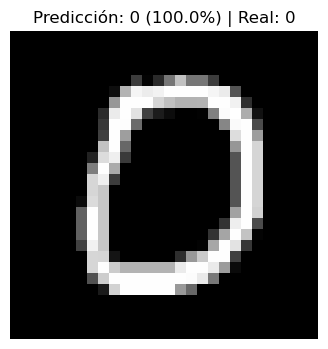

In [19]:
sample_idx = 10
sample_img = x_test[sample_idx]
true_label = y_test[sample_idx]

# Inferencia: expandimos a dimensión batch (1, 28, 28)
pred_probs = cudnn_model.predict(np.expand_dims(sample_img, axis=0), verbose=0)
pred_label = np.argmax(pred_probs, axis=1)[0]
confidence = pred_probs[0][pred_label] * 100

plt.figure(figsize=(4, 4))
plt.imshow(sample_img, cmap="gray")
plt.title(f"Predicción: {pred_label} ({confidence:.1f}%) | Real: {true_label}")
plt.axis("off")
plt.show()


1. **Memoria Temporal y Recurrencia**: Las RNN introducen bucles que permiten modelar datos secuenciales pasando un estado oculto $h_t$ a través del tiempo.
2. **El Reto de BPTT**: Las RNN simples sufren de desvanecimiento o explosión del gradiente al multiplicarse repetidamente matrices de pesos a lo largo de muchos pasos temporales.
3. **Mecanismo de Compuertas (LSTM y GRU)**:
   - **LSTM**: Regula el flujo mediante compuertas de olvido ($f_t$), entrada ($i_t$) y salida ($o_t$), sumando aditivamente al estado de celda $C_t$.
   - **GRU**: Simplifica la celda fusionando estados con compuertas de actualización ($z_t$) y reinicio ($r_t$), logrando una excelente relación entre precisión y eficiencia computacional.
4. **Configuración en Frameworks Modernos**:
   - `return_sequences=True` es indispensable al apilar capas recurrentes consecutivas.
   - `return_state=True` permite extraer los vectores de estado para arquitecturas Codificador-Decodificador (Seq2Seq).
   - `layers.Bidirectional` procesa la secuencia en ambas direcciones temporales, aumentando la capacidad expresiva en tareas de contexto bidireccional.
   - Mantener las configuraciones estándar en Keras asegura el aprovechamiento automático de los kernels acelerados por hardware **CuDNN**.